# Clasificación `titanic.csv`

In [1]:
import pandas as pd
import seaborn as sns
from sklearn import linear_model
import numpy as np

import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.rc("font", size=14)

## Limitaciones de la Regresión Lineal

In [2]:
lst1 = [*range(10, 30)]
lst2 = [0,0,0,0,0,0,0,0,0,1,0,1,1,1,1,1,1,1,1,1]

In [3]:
print(lst1)
print(lst2)

[10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1]


In [4]:
df = pd.DataFrame(list(zip(lst1, lst2)),
columns =['edad', 'compra'])
df.head()

,edad,compra
0,10,0
1,11,0
2,12,0
3,13,0
4,14,0


<Axes: xlabel='edad', ylabel='compra'>

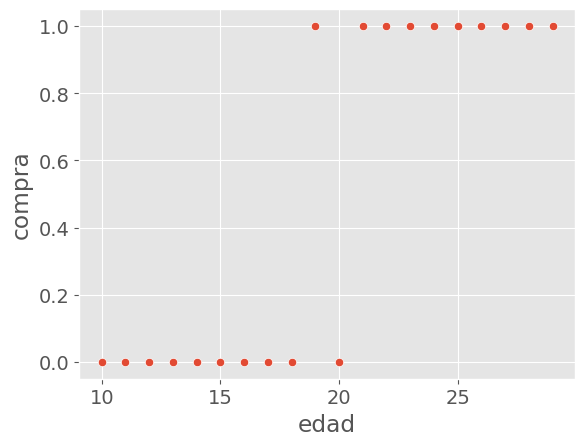

In [5]:
sns.scatterplot(data=df, x="edad", y="compra")

In [6]:
X = df['edad'].values.reshape(-1, 1)
y = df['compra'].values.reshape(-1, 1)

reg = linear_model.LinearRegression()
reg = reg.fit(X, y)

In [7]:
df['compra_pred'] = reg.predict(X)
df.head()

,edad,compra,compra_pred
0,10,0,-0.200000
1,11,0,-0.126316
2,12,0,-0.052632
3,13,0,0.021053
4,14,0,0.094737


<Axes: xlabel='edad', ylabel='compra'>

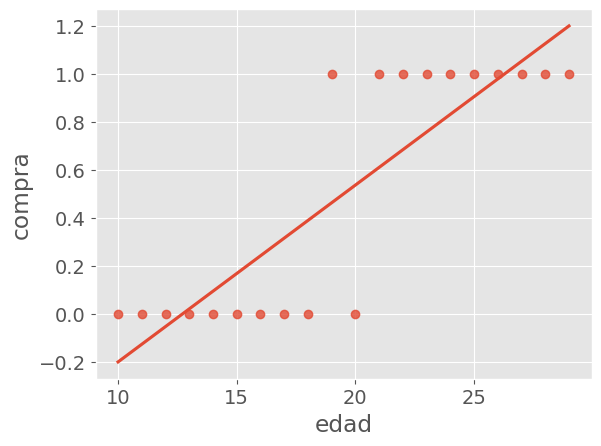

In [8]:
sns.regplot(data=df, x="edad", y="compra", ci=None)

<Axes: xlabel='edad', ylabel='compra'>

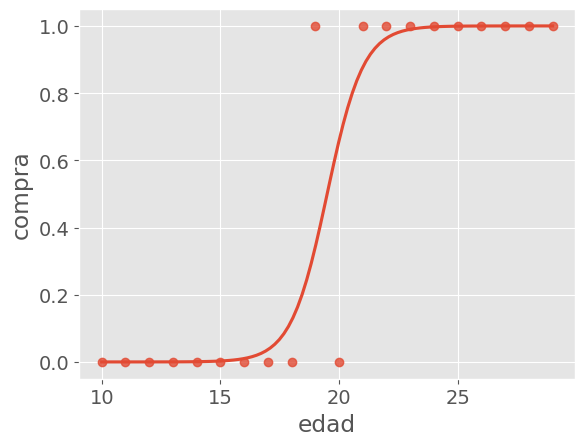

In [9]:
sns.regplot(data=df, x="edad", y="compra", logistic=True, ci=None)

## Regresión Logística

In [10]:
from sklearn import preprocessing
from sklearn.linear_model import LogisticRegression

import seaborn as sns
sns.set(style="white")
sns.set(style="whitegrid", color_codes=True)

In [11]:
titanic = pd.read_csv('titanic.csv')

In [12]:
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [13]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Preparación del dataset
Vamos a conservar solo algunas de las variables:

In [14]:
columns = ['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Fare', 'Embarked']

df = titanic[columns]
df.dropna(inplace = True) #eliminamos los registros con faltantes

/tmp/ipykernel_25985/1500738533.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace = True) #eliminamos los registros con faltantes


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  712 non-null    int64  
 1   Pclass    712 non-null    int64  
 2   Sex       712 non-null    object 
 3   Age       712 non-null    float64
 4   SibSp     712 non-null    int64  
 5   Fare      712 non-null    float64
 6   Embarked  712 non-null    object 
dtypes: float64(2), int64(3), object(2)
memory usage: 44.5+ KB


Vamos a usar la libreria **[Pandas Profiling](https://github.com/pandas-profiling/pandas-profiling)** para realizar un breve análisis exploratorio del dataset.

In [16]:
#pip install -U pandas-profiling

In [17]:
from pandas_profiling import ProfileReport

/tmp/ipykernel_25985/2274191625.py:1: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  from pandas_profiling import ProfileReport


In [18]:
# Generate the Profiling Report
profile = ProfileReport(df)

In [19]:
# Or use the HTML report in an iframe
profile
# Si no ves el output interactivo abajo de esta celda, volver a ejecutar en Colab

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 7/7 [00:00<00:00, 38.17it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Realizamos la transformación del **One-Hot-Encoder** para las variables categróricas. Recordamos no caer en la *trampa dummy*.

In [20]:
cat_vars = ['Sex', 'Pclass', 'Embarked']

for var in cat_vars:
    cat_list='var'+'_'+var
    cat_list = pd.get_dummies(df[var], prefix=var, drop_first=True) #el parametro drop_first elimina la posibilidad de caer en una trampa dummy
    df_1=df.join(cat_list)
    df=df_1

In [21]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Fare,Embarked,Sex_male,Pclass_2,Pclass_3,Embarked_Q,Embarked_S
0,0,3,male,22.0,1,7.2500,S,True,False,True,False,True
1,1,1,female,38.0,1,71.2833,C,False,False,False,False,False
2,1,3,female,26.0,0,7.9250,S,False,False,True,False,True
3,1,1,female,35.0,1,53.1000,S,False,False,False,False,True
4,0,3,male,35.0,0,8.0500,S,True,False,True,False,True


In [22]:
data_vars = df.columns.values.tolist()
to_keep = [i for i in data_vars if i not in cat_vars]
df_final=df[to_keep]

In [23]:
df_final.head()

,Survived,Age,SibSp,Fare,Sex_male,Pclass_2,Pclass_3,Embarked_Q,Embarked_S
0,0,22.0,1,7.2500,True,False,True,False,True
1,1,38.0,1,71.2833,False,False,False,False,False
2,1,26.0,0,7.9250,False,False,True,False,True
3,1,35.0,1,53.1000,False,False,False,False,True
4,0,35.0,0,8.0500,True,False,True,False,True


In [24]:
df = df_final

## Modelo

Vamos a sar el módulo [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) de sklearn

In [25]:
#from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [26]:
# Partición en train y test
y = df.loc[:, df.columns == 'Survived']
X = df.loc[:, df.columns != 'Survived']

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99)

In [27]:
# instancia del modelo
logisticRegr = LogisticRegression(max_iter=10000)

In [28]:
# entrenamiento
logisticRegr.fit(x_train, y_train)
#logisticRegr.fit(x_train, y_train, solver='liblinear')

/home/byob/Documents/Computational/lib/python3.13/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [29]:
# performance
y_pred = logisticRegr.predict(x_test)
print('El accuracy de nuestra regresión logística en el set de test es: {:.2f}'.format(logisticRegr.score(x_test, y_test)))

El accuracy de nuestra regresión logística en el set de test es: 0.78


## Interpretación

In [30]:
logisticRegr.coef_

array([[-0.042963  , -0.35251361,  0.00316147, -2.31339594, -0.87126009,
        -2.06781717, -0.68698987, -0.62311015]])

In [31]:
logisticRegr.intercept_

array([4.05526396])

In [32]:
coeficientes= pd.DataFrame(logisticRegr.coef_[0],
                X.columns,
                columns=['coef'])
coeficientes

,coef
Age,-0.042963
SibSp,-0.352514
Fare,0.003161
Sex_male,-2.313396
Pclass_2,-0.871260
Pclass_3,-2.067817
Embarked_Q,-0.686990
Embarked_S,-0.623110


## Métricas de evaluación



**Matriz de confusión**

Observación: la matriz de confsión de sklearn está espejada respecto a lo visto en la teoría:

                                tn fp
                                fn tp

In [33]:
from sklearn.metrics import confusion_matrix

In [34]:
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[74 11]
 [21 37]]


In [35]:
from sklearn.metrics import plot_confusion_matrix

ImportError: cannot import name 'plot_confusion_matrix' from 'sklearn.metrics' (/home/byob/Documents/Computational/lib/python3.13/site-packages/sklearn/metrics/__init__.py)

In [ ]:
class_names = ['no sobrevive', 'sobrevive']

disp = plot_confusion_matrix(logisticRegr, x_test, y_test,
                              display_labels=class_names,
                              cmap=plt.cm.Blues)

print(disp.confusion_matrix)

**Precision, Recall y F-Score**

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [ ]:
# accuracy: (tp + tn) / (p + n)
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: %f' % accuracy)

# precision tp / (tp + fp)
precision = precision_score(y_test, y_pred)
print('Precision: %f' % precision)

# recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)
print('Recall: %f' % recall)

# f1: 2 tp / (2 tp + fp + fn)
f1 = f1_score(y_test, y_pred)
print('F1 score: %f' % f1)

**ROC**

In [ ]:
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [ ]:
logit_roc_auc = roc_auc_score(y_test, logisticRegr.predict(x_test))
fpr, tpr, thresholds = roc_curve(y_test, logisticRegr.predict_proba(x_test)[:,1])

In [ ]:
plt.figure()
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

Veamos que sucede si entrenamos un modelos con **menor cantidad de variables**

In [ ]:
# Partición en train y test
y_2 = df.loc[:, df.columns == 'Survived']
X_2 = df.loc[:, ['Age', 'Embarked_Q', 'Embarked_S']]

x_train_2, x_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=99)

In [ ]:
logisticRegr_2 = LogisticRegression(max_iter=10000)
logisticRegr_2.fit(x_train_2, y_train_2)

In [ ]:
y_pred_2 = logisticRegr_2.predict(x_test_2)

Matriz de confusión

In [ ]:
class_names = ['no sobrevive', 'sobrevive']

disp_2 = plot_confusion_matrix(logisticRegr_2, x_test_2, y_test_2,
                              display_labels=class_names,
                              cmap=plt.cm.Blues)

print(disp_2.confusion_matrix)

Métricas varias

In [ ]:
# accuracy: (tp + tn) / (p + n)
accuracy_2=accuracy_score(y_test_2, y_pred_2)
print('Accuracy: %f' % accuracy_2)

# precision tp / (tp + fp)
precision_2 = precision_score(y_test_2, y_pred_2)
print('Precision: %f' % precision_2)

# recall: tp / (tp + fn)
recall_2 = recall_score(y_test_2, y_pred_2)
print('Recall: %f' % recall_2)

# f1: 2 tp / (2 tp + fp + fn)
f1_2 = f1_score(y_test_2, y_pred_2)
print('F1 score: %f' % f1_2)

Curva ROC

In [ ]:
logit_roc_auc_2 = roc_auc_score(y_test_2, logisticRegr_2.predict(x_test_2))
fpr_2, tpr_2, thresholds_2 = roc_curve(y_test_2, logisticRegr_2.predict_proba(x_test_2)[:,1])

plt.figure()
plt.plot(fpr_2, tpr_2, label='Logistic Regression (area = %0.2f)' % logit_roc_auc_2)
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.savefig('Log_ROC')
plt.show()

## Balanceo de clases

In [ ]:
#pip install -U scikit-learn

In [ ]:
df = df_final

In [ ]:
df.Survived.value_counts()

In [ ]:
df.Survived.value_counts()/df_final.Survived.count()*100

Veamos si balanceando nuestras clases podemos mejorar la performance de nuestro modelo.

## Subsampleo de clase mayoritaria

In [ ]:
y = df.loc[:, df.columns == 'Survived']
X = df.loc[:, df.columns != 'Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99)

In [ ]:
train = X_train
train['Survived'] = y_train.Survived.to_list()

positivos = train[train.Survived == 1]
print(len(positivos))
negativos = train[train.Survived == 0]
print(len(negativos))

In [ ]:
negativos_sub = negativos.sample(n=len(positivos), random_state=99)
len(negativos_sub)

In [ ]:
train_sub = pd.concat([positivos, negativos_sub])
len(train_sub)

In [ ]:
y_train = train_sub.loc[:, train_sub.columns == 'Survived']
X_train = train_sub.loc[:, train_sub.columns != 'Survived']

In [ ]:
# instancia del modelo
logisticRegr = LogisticRegression(max_iter=10000)

In [ ]:
# entrenamiento
logisticRegr.fit(X_train, y_train)

In [ ]:
y_pred = logisticRegr.predict(X_test)

# accuracy: (tp + tn) / (p + n)
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: %f' % accuracy)

# precision tp / (tp + fp)
precision = precision_score(y_test, y_pred)
print('Precision: %f' % precision)

# recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)
print('Recall: %f' % recall)

# f1: 2 tp / (2 tp + fp + fn)
f1 = f1_score(y_test, y_pred)
print('F1 score: %f' % f1)

## SMOTE

In [ ]:
#!pip install scikit-learn==0.23.1
#!pip install imblearn

In [ ]:
from imblearn.over_sampling import SMOTE
os = SMOTE(random_state=0)

In [ ]:
y = df.loc[:, df.columns == 'Survived']
X = df.loc[:, df.columns != 'Survived']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=99)

columns = X_train.columns
os_data_X,os_data_y=os.fit_sample(X_train, y_train)

os_data_X = pd.DataFrame(data=os_data_X,columns=columns )
os_data_y= pd.DataFrame(data=os_data_y,columns=['y'])

In [ ]:
print("length of oversampled data is ",len(os_data_X))
print("Number of 0 in oversampled data",len(os_data_y[os_data_y['y']==0]))
print("Number of 1",len(os_data_y[os_data_y['y']==1]))
print("Proportion of 0 data in oversampled data is ",len(os_data_y[os_data_y['y']==0])/len(os_data_X))
print("Proportion of 1 data in oversampled data is ",len(os_data_y[os_data_y['y']==1])/len(os_data_X))

In [ ]:
# instancia del modelo
logisticRegr = LogisticRegression(max_iter=10000)

In [ ]:
# entrenamiento
logisticRegr.fit(os_data_X, os_data_y)

In [ ]:
y_pred = logisticRegr.predict(X_test)

# accuracy: (tp + tn) / (p + n)
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy: %f' % accuracy)

# precision tp / (tp + fp)
precision = precision_score(y_test, y_pred)
print('Precision: %f' % precision)

# recall: tp / (tp + fn)
recall = recall_score(y_test, y_pred)
print('Recall: %f' % recall)

# f1: 2 tp / (2 tp + fp + fn)
f1 = f1_score(y_test, y_pred)
print('F1 score: %f' % f1)